# HealthConnect Appointment Analytics — Week 5

## Data Analytics Track

### Objective

This notebook presents the Week 5 practical analytics work for the HealthConnect project.

The analysis focuses on appointment attendance and no-show patterns, with the aim of identifying meaningful trends, calculating key performance indicators (KPIs), and developing evidence-based recommendations that could support HealthConnect's appointment management and patient engagement strategies.

### Week 5 Objectives

- Prepare and assess the HealthConnect appointment dataset
- Conduct exploratory data analysis (EDA)
- Calculate key performance indicators (KPIs)
- Analyse factors associated with appointment no-shows
- Create analytical visualisations
- Identify at least five meaningful business insights
- Develop evidence-based recommendations
- Document assumptions and limitations
- Prepare findings for the Week 6 project stage

## 1. Import Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Load the Dataset

In [36]:
df = pd.read_excel(r"C:\Users\DELL\Documents\HealthConnect_Project\HealthConnect_Appointment_Data.xlsx")

df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## 3. Initial Dataset Assessment

The first assessment examines the structure, dimensions, data types, missing values, and duplicate records in the dataset before conducting further analysis.

In [37]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (5000, 18)

Column names:
['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome']

Data types:
appointment_id                      str
patient_id                          str
gender                              str
age                               int64
age_group                           str
appointment_type                    str
booking_date             datetime64[us]
appointment_date         datetime64[us]
appointment_day                     str
appointment_time                    str
booking_lead_days                 int64
previous_appointments             int64
previous_no_shows                 int64
reminder_sent                       str
reminder_channel                    str
distance_to_

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   appointment_id         5000 non-null   str           
 1   patient_id             5000 non-null   str           
 2   gender                 5000 non-null   str           
 3   age                    5000 non-null   int64         
 4   age_group              5000 non-null   str           
 5   appointment_type       5000 non-null   str           
 6   booking_date           5000 non-null   datetime64[us]
 7   appointment_date       5000 non-null   datetime64[us]
 8   appointment_day        5000 non-null   str           
 9   appointment_time       5000 non-null   str           
 10  booking_lead_days      5000 non-null   int64         
 11  previous_appointments  5000 non-null   int64         
 12  previous_no_shows      5000 non-null   int64         
 13  reminder_sent 

In [39]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
appointment_id,5000,5000,HC-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,5000,1696,P-1776,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,5000,3,Female,2488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,48.7948,18.0,33.0,49.0,64.0,80.0,18.138547
age_group,5000,6,65+,1241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_type,5000,4,General Consultation,2086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,5000,NaN,NaN,NaN,2025-08-31 03:01:09.120000,2024-11-07 00:00:00,2025-04-15 00:00:00,2025-08-28 00:00:00,2026-01-16 06:00:00,2026-06-27 00:00:00,NaN
appointment_date,5000,NaN,NaN,NaN,2025-09-29 18:20:44.160000,2025-01-01 00:00:00,2025-05-15 00:00:00,2025-09-27 00:00:00,2026-02-15 00:00:00,2026-06-30 00:00:00,NaN
appointment_day,5000,7,Wednesday,737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_time,5000,3,Morning,2227,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Quality Assessment

Before conducting exploratory analysis, the dataset is assessed for missing values, duplicate records, inconsistent categorical values, and potential data-quality issues.

This step helps ensure that the subsequent KPI calculations and visualisations are based on a reliable analytical dataset.

In [40]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary.sort_values("Missing Values", ascending=False)

,Missing Values,Missing Percentage
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


In [41]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Categorical Variable Assessment

Categorical variables are reviewed to identify unexpected, inconsistent, or duplicated category labels.

In [42]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- appointment_id ---
appointment_id
HC-00001    1
HC-00002    1
HC-00003    1
HC-00004    1
HC-00005    1
           ..
HC-04996    1
HC-04997    1
HC-04998    1
HC-04999    1
HC-05000    1
Name: count, Length: 5000, dtype: int64

--- patient_id ---
patient_id
P-1776    9
P-1742    9
P-1399    9
P-1104    8
P-0780    8
         ..
P-0228    1
P-0050    1
P-0313    1
P-0730    1
P-1262    1
Name: count, Length: 1696, dtype: int64

--- gender ---
gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

--- age_group ---
age_group
65+      1241
35-44     819
55-64     800
45-54     793
25-34     783
18-24     564
Name: count, dtype: int64

--- appointment_type ---
appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

--- appointment_day ---
appointment_day
Wednesday    737
Sunday       737
Friday       728
Saturday 

C:\Users\DELL\AppData\Local\Temp\ipykernel_20776\3264635065.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Male
Female

## 5. Create the Analytical Dataset

For the main attendance and no-show analysis, appointments with an outcome of "Attended" or "No-Show" are retained.

Cancelled appointments are excluded from the primary no-show analysis because a cancellation is operationally different from failing to attend a scheduled appointment.

The original dataset is preserved, while a separate analytical dataset is created for the Week 5 analysis.

In [43]:
analysis_df = df[
    df["appointment_outcome"].isin(["Attended", "No-Show"])
].copy()

print("Original dataset:", df.shape)
print("Analytical dataset:", analysis_df.shape)

analysis_df["appointment_outcome"].value_counts()

Original dataset: (5000, 18)
Analytical dataset: (4737, 18)


appointment_outcome
No-Show     2423
Attended    2314
Name: count, dtype: int64

### Creating the No-Show Indicator

A binary indicator is created to support KPI calculations and comparisons across different appointment characteristics.

- 1 = No-Show
- 0 = Attended

In [44]:
analysis_df["no_show_flag"] = (
    analysis_df["appointment_outcome"] == "No-Show"
).astype(int)

analysis_df[["appointment_outcome", "no_show_flag"]].head(10)

,appointment_outcome,no_show_flag
0,No-Show,1
1,Attended,0
2,No-Show,1
3,Attended,0
4,No-Show,1
5,No-Show,1
6,No-Show,1
7,Attended,0
8,No-Show,1
9,Attended,0


## 6. Key Performance Indicators (KPIs)

The following KPIs are calculated to measure appointment attendance performance and identify potential areas for operational improvement.

The selected KPIs build on the measures proposed during Week 4:

1. No-Show Rate
2. Attendance Rate
3. Reminder Effectiveness
4. No-Show Rate by Appointment Type
5. Repeat No-Show Rate

In [45]:
total_eligible = len(analysis_df)

total_no_shows = analysis_df["no_show_flag"].sum()

total_attended = (
    analysis_df["appointment_outcome"] == "Attended"
).sum()

no_show_rate = total_no_shows / total_eligible * 100
attendance_rate = total_attended / total_eligible * 100

print(f"Eligible appointments: {total_eligible:,}")
print(f"Attended appointments: {total_attended:,}")
print(f"No-show appointments: {total_no_shows:,}")
print(f"No-Show Rate: {no_show_rate:.2f}%")
print(f"Attendance Rate: {attendance_rate:.2f}%")

Eligible appointments: 4,737
Attended appointments: 2,314
No-show appointments: 2,423
No-Show Rate: 51.15%
Attendance Rate: 48.85%


## 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is conducted to identify patterns and relationships in appointment attendance and no-show behaviour.

The analysis focuses on appointment characteristics, patient history, reminder activity, scheduling factors, and other variables that may be associated with appointment outcomes.

### 7.1 Overall Appointment Outcome

In [46]:
outcome_counts = analysis_df["appointment_outcome"].value_counts()

outcome_counts

appointment_outcome
No-Show     2423
Attended    2314
Name: count, dtype: int64

In [47]:
outcome_percentages = (
    analysis_df["appointment_outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

outcome_percentages

appointment_outcome
No-Show     51.15
Attended    48.85
Name: proportion, dtype: float64

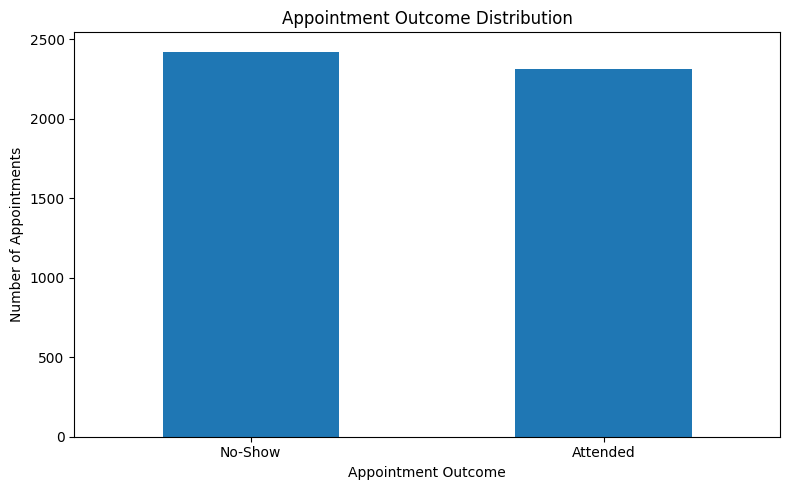

In [48]:
plt.figure(figsize=(8, 5))

outcome_counts.plot(kind="bar")

plt.title("Appointment Outcome Distribution")
plt.xlabel("Appointment Outcome")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 7.2 No-Show Rate by Appointment Type

This analysis compares no-show rates across appointment types to determine whether attendance behaviour differs between different categories of appointments.

In [49]:
appointment_type_rate = (
    analysis_df.groupby("appointment_type")["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

appointment_type_rate

appointment_type
Follow-up                  54.17
Diagnostic Test            52.03
Specialist Consultation    50.47
General Consultation       49.14
Name: no_show_flag, dtype: float64

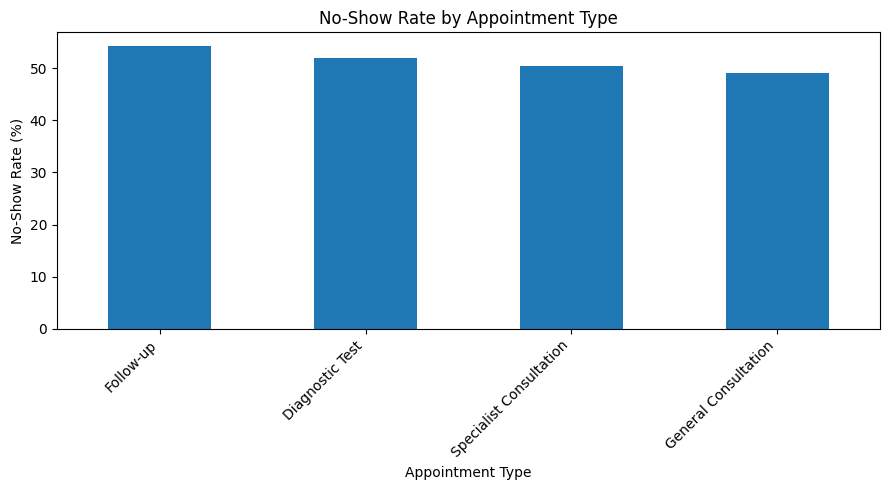

In [50]:
plt.figure(figsize=(9, 5))

appointment_type_rate.plot(kind="bar")

plt.title("No-Show Rate by Appointment Type")
plt.xlabel("Appointment Type")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 7.3 Reminder Status and No-Show Rate

This analysis compares appointment no-show rates between appointments where a reminder was sent and appointments where no reminder was recorded.

In [51]:
reminder_rate = (
    analysis_df.groupby("reminder_sent")["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
)

reminder_rate

reminder_sent
No     54.63
Yes    49.86
Name: no_show_flag, dtype: float64

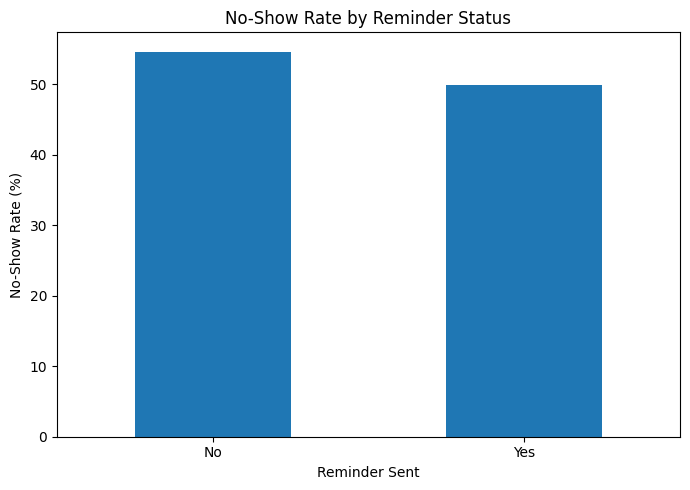

In [52]:
plt.figure(figsize=(7, 5))

reminder_rate.plot(kind="bar")

plt.title("No-Show Rate by Reminder Status")
plt.xlabel("Reminder Sent")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 7.4 No-Show Rate by Reminder Channel

This analysis compares attendance behaviour across the different reminder channels recorded in the dataset.

In [53]:
reminder_channel_rate = (
    analysis_df.groupby("reminder_channel")["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

reminder_channel_rate

reminder_channel
WhatsApp    52.74
Email       50.99
SMS         47.98
Name: no_show_flag, dtype: float64

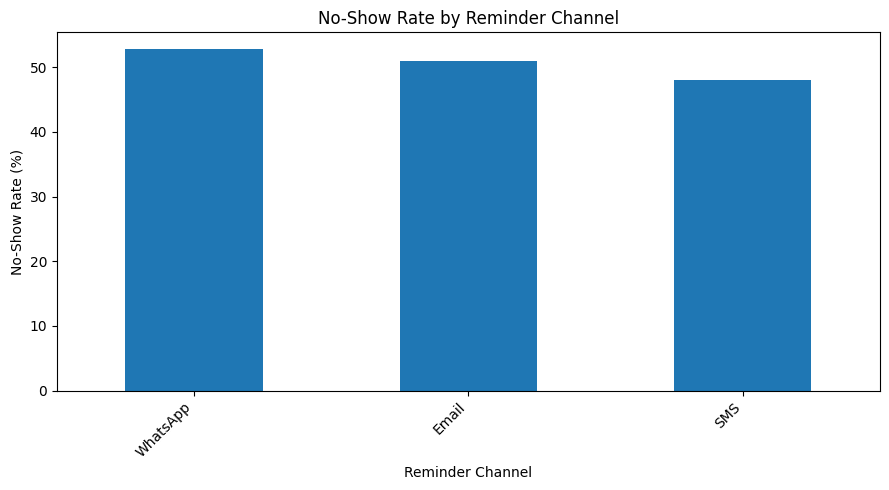

In [54]:
plt.figure(figsize=(9, 5))

reminder_channel_rate.plot(kind="bar")

plt.title("No-Show Rate by Reminder Channel")
plt.xlabel("Reminder Channel")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 7.5 Previous No-Show History

This analysis investigates whether patients with a history of previous no-shows have different attendance behaviour from patients with fewer or no previous no-shows.

In [55]:
previous_noshow_rate = (
    analysis_df.groupby("previous_no_shows")["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
)

previous_noshow_rate

previous_no_shows
0     46.30
1     55.87
2     62.05
3     69.74
4     66.67
5    100.00
Name: no_show_flag, dtype: float64

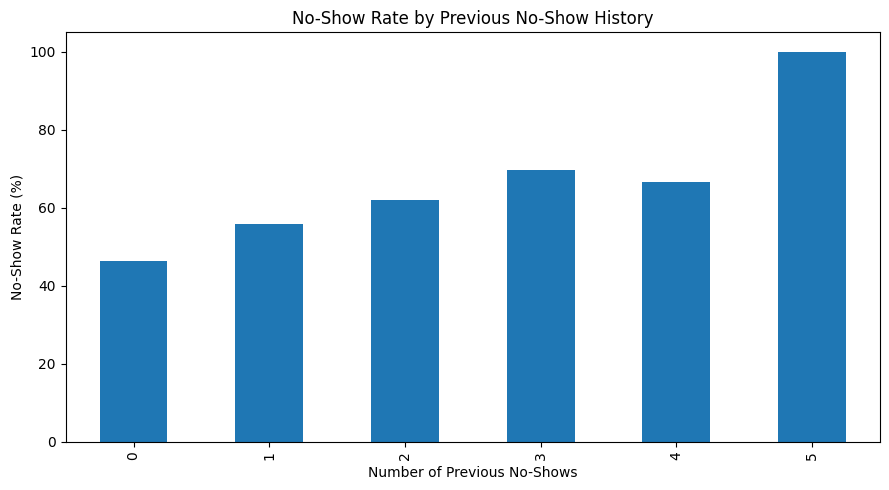

In [56]:
plt.figure(figsize=(9, 5))

previous_noshow_rate.plot(kind="bar")

plt.title("No-Show Rate by Previous No-Show History")
plt.xlabel("Number of Previous No-Shows")
plt.ylabel("No-Show Rate (%)")

plt.tight_layout()
plt.show()

### 7.6 Booking Lead Time and No-Show Rate

Booking lead time is grouped into practical intervals to examine whether attendance behaviour changes depending on how far in advance an appointment was scheduled.

In [57]:
bins = [0, 7, 14, 30, 60, np.inf]
labels = ["0–7 days", "8–14 days", "15–30 days", "31–60 days", "61+ days"]

analysis_df["lead_time_group"] = pd.cut(
    analysis_df["booking_lead_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

lead_time_rate = (
    analysis_df.groupby("lead_time_group", observed=False)["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
)

lead_time_rate

lead_time_group
0–7 days      29.47
8–14 days     35.19
15–30 days    45.53
31–60 days    63.95
61+ days        NaN
Name: no_show_flag, dtype: float64

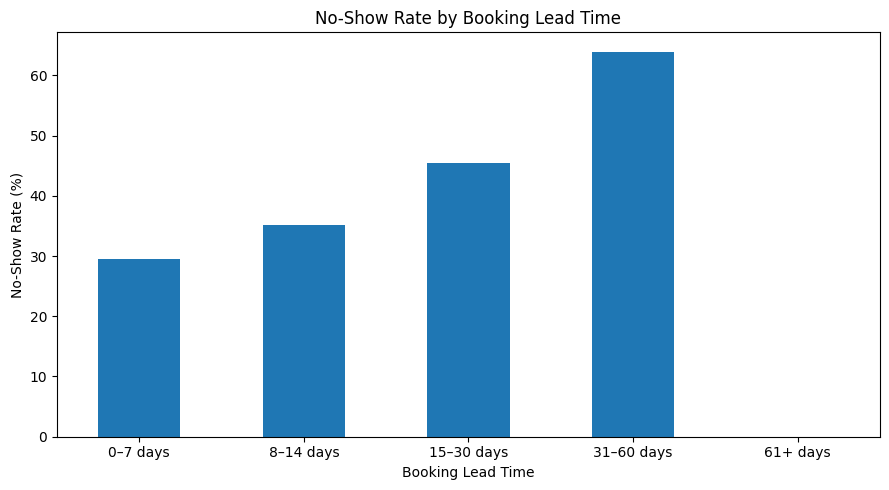

In [58]:
plt.figure(figsize=(9, 5))

lead_time_rate.plot(kind="bar")

plt.title("No-Show Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 7.7 No-Show Rate by Appointment Day

This analysis examines whether no-show rates vary across the days of the week.

In [59]:
day_rate = (
    analysis_df.groupby("appointment_day")["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

day_rate

appointment_day
Monday       53.13
Sunday       52.84
Wednesday    52.81
Thursday     52.02
Saturday     49.63
Tuesday      48.94
Friday       48.71
Name: no_show_flag, dtype: float64

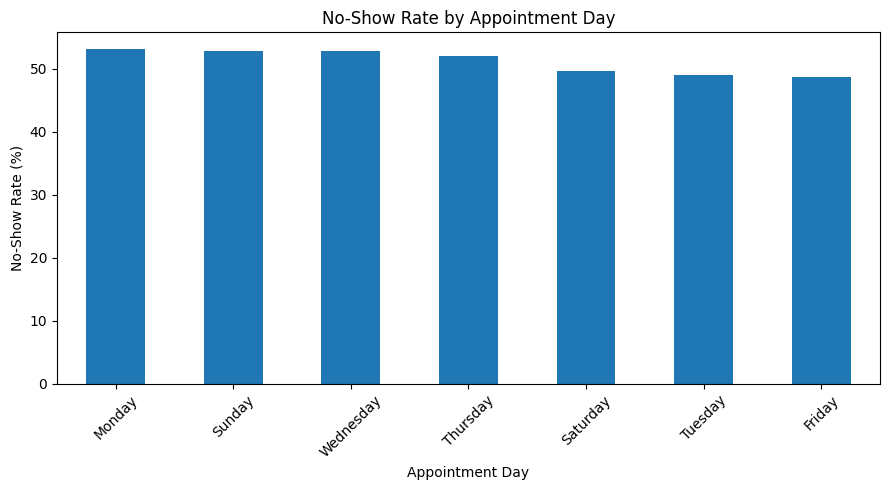

In [60]:
plt.figure(figsize=(9, 5))

day_rate.plot(kind="bar")

plt.title("No-Show Rate by Appointment Day")
plt.xlabel("Appointment Day")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 7.8 No-Show Rate by Age Group

Age groups are compared to determine whether attendance behaviour varies across different patient age categories.

In [61]:
age_rate = (
    analysis_df.groupby("age_group")["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

age_rate

age_group
55-64    53.00
25-34    52.93
18-24    52.41
35-44    51.43
45-54    51.07
65+      48.07
Name: no_show_flag, dtype: float64

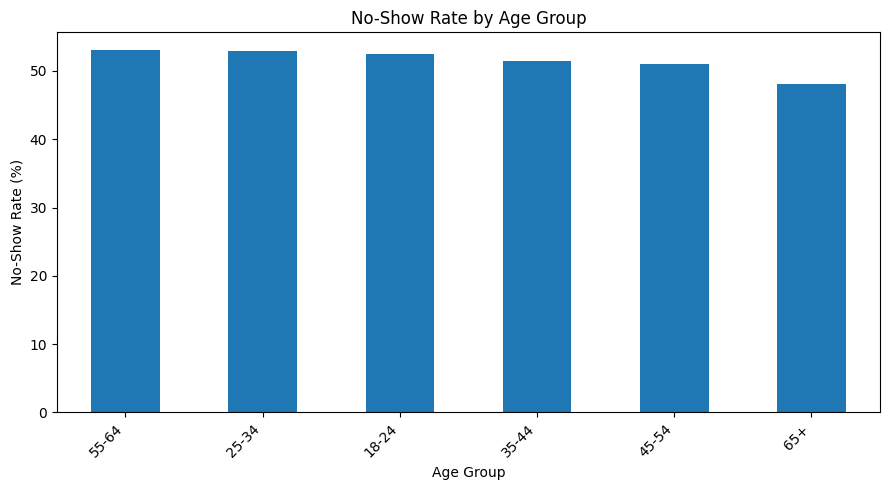

In [62]:
plt.figure(figsize=(9, 5))

age_rate.plot(kind="bar")

plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 8. KPI Summary

The following table summarises the key performance indicators calculated from the analytical dataset. These KPIs provide a concise view of appointment attendance performance and support the identification of areas requiring further investigation.

In [63]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Eligible Appointments",
        "Attended Appointments",
        "No-Show Appointments",
        "Attendance Rate",
        "No-Show Rate"
    ],
    "Value": [
        total_eligible,
        total_attended,
        total_no_shows,
        f"{attendance_rate:.2f}%",
        f"{no_show_rate:.2f}%"
    ]
})

kpi_summary

,KPI,Value
0,Eligible Appointments,4737
1,Attended Appointments,2314
2,No-Show Appointments,2423
3,Attendance Rate,48.85%
4,No-Show Rate,51.15%


## 9. Reminder Effectiveness

Reminder effectiveness is assessed by comparing attendance and no-show rates between appointments where a reminder was sent and appointments where no reminder was recorded.

This analysis is used to identify whether reminder status is associated with differences in appointment attendance.

In [64]:
reminder_summary = (
    analysis_df.groupby("reminder_sent")["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

reminder_summary["Attendance_Rate"] = 1 - reminder_summary["No_Show_Rate"]

reminder_summary["No_Show_Rate"] = (
    reminder_summary["No_Show_Rate"] * 100
).round(2)

reminder_summary["Attendance_Rate"] = (
    reminder_summary["Attendance_Rate"] * 100
).round(2)

reminder_summary

,Appointments,No_Shows,No_Show_Rate,Attendance_Rate
reminder_sent,,,,
No,1285,702,54.63,45.37
Yes,3452,1721,49.86,50.14


## 10. Repeat No-Show Analysis

This analysis examines whether patients with previous no-show records have different attendance behaviour from patients with no previous no-shows.

The purpose is to determine whether previous attendance behaviour may help identify groups that require additional appointment engagement.

In [65]:
repeat_noshow_summary = (
    analysis_df.groupby("previous_no_shows")["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

repeat_noshow_summary["No_Show_Rate"] = (
    repeat_noshow_summary["No_Show_Rate"] * 100
).round(2)

repeat_noshow_summary

,Appointments,No_Shows,No_Show_Rate
previous_no_shows,,,
0,2745,1271,46.30
1,1482,828,55.87
2,419,260,62.05
3,76,53,69.74
4,12,8,66.67
5,3,3,100.00


In [66]:
analysis_df["previous_noshow_group"] = np.where(
    analysis_df["previous_no_shows"] > 0,
    "Previous No-Show",
    "No Previous No-Show"
)

previous_noshow_group_rate = (
    analysis_df.groupby("previous_noshow_group")["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
)

previous_noshow_group_rate

previous_noshow_group
No Previous No-Show    46.30
Previous No-Show       57.83
Name: no_show_flag, dtype: float64

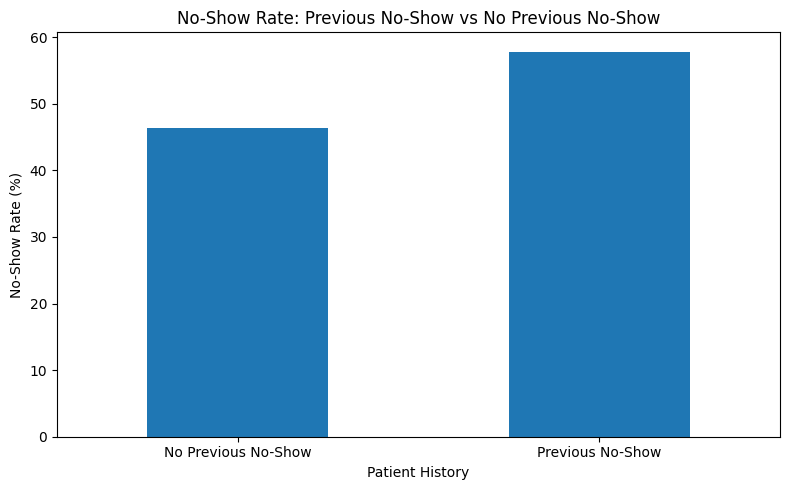

In [67]:
plt.figure(figsize=(8, 5))

previous_noshow_group_rate.plot(kind="bar")

plt.title("No-Show Rate: Previous No-Show vs No Previous No-Show")
plt.xlabel("Patient History")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 11. No-Show Rate by Gender

No-show rates are compared across gender categories to determine whether there are notable differences in appointment attendance behaviour.

In [68]:
gender_rate = (
    analysis_df.groupby("gender")["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

gender_rate

gender
Male                 51.50
Female               51.10
Prefer not to say    44.76
Name: no_show_flag, dtype: float64

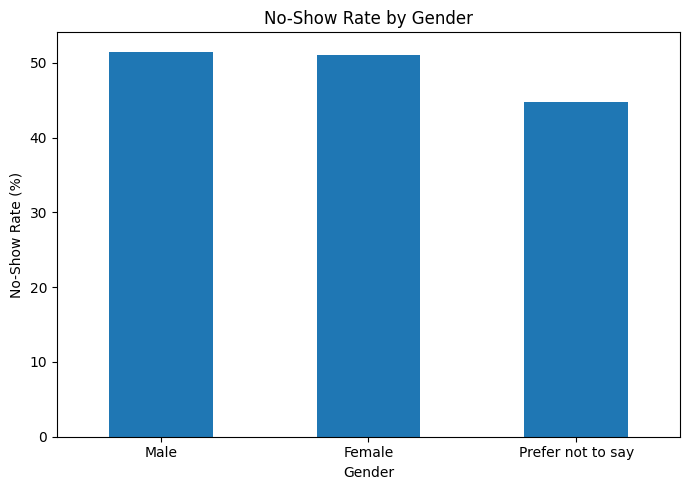

In [69]:
plt.figure(figsize=(7, 5))

gender_rate.plot(kind="bar")

plt.title("No-Show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 12. Business Recommendations

Based on the findings from the exploratory data analysis and KPI assessment, the following recommendations are proposed to support HealthConnect's appointment attendance and patient engagement objectives.

### Recommendation 1 — Strengthen Reminder Strategies

HealthConnect should review and strengthen its appointment reminder strategy, particularly for patient groups or appointment categories that demonstrate higher no-show rates.

Reminder activity should be monitored regularly to identify opportunities to improve reminder coverage and timing.

### Recommendation 2 — Target Patients with Previous No-Shows

Patients with a history of previous no-shows should be considered a priority group for targeted appointment engagement.

HealthConnect could consider additional reminders or confirmation requests for patients with repeated missed appointments.

### Recommendation 3 — Review High-Risk Appointment Categories

Appointment types with comparatively higher no-show rates should be monitored more closely.

HealthConnect could investigate whether differences in appointment type, scheduling process, or patient communication are contributing to the observed attendance patterns.

### Recommendation 4 — Use Booking Lead Time to Support Engagement

Where longer booking lead times are associated with increased no-show rates, HealthConnect could consider additional reminder touchpoints closer to the appointment date.

### Recommendation 5 — Use Analytics for Ongoing Monitoring

HealthConnect should continue monitoring attendance and no-show KPIs over time.

A Power BI dashboard can support ongoing monitoring by allowing stakeholders to examine no-show patterns across appointment types, reminder status, patient characteristics, and scheduling factors.

## 13. Limitations

Several limitations should be considered when interpreting the results of this analysis.

### 1. Dataset Scope

The analysis is based on the available HealthConnect appointment dataset and may not represent all patients, appointments, or operational conditions that could exist in a real healthcare environment.

### 2. Missing Values

Some variables contain missing values, including reminder channel, distance to the clinic, and waiting time. These missing observations may affect analyses involving these variables.

### 3. Cancelled Appointments

Cancelled appointments were excluded from the primary attendance/no-show analysis because cancellation is operationally different from failing to attend an appointment.

### 4. Association Does Not Imply Causation

The analysis identifies patterns and associations within the dataset. The observed relationships should not be interpreted as evidence that one variable directly causes another.

### 5. Data Quality and Measurement

The analysis depends on the accuracy and consistency of the information recorded in the dataset. Any errors or inconsistencies in the underlying data may affect the results.

### 6. Predictive Limitations

The analysis is primarily descriptive and exploratory. The identified patterns should not be treated as a predictive model of individual patient behaviour without further validation and modelling.

## 14. Week 5 Project Summary

### Planned Work

The planned Week 5 work was to move from the initial planning and dataset exploration completed in Week 4 into practical data preparation, exploratory analysis, KPI development, and visualisation.

### Completed Work

During Week 5, the HealthConnect appointment dataset was assessed and prepared for analysis. Missing values, duplicate records, categorical variables, and appointment outcomes were reviewed.

An analytical dataset containing attended and no-show appointments was created for the primary attendance analysis, while cancelled appointments were excluded from the main no-show calculations.

Exploratory analysis was conducted across appointment characteristics, reminder activity, patient history, booking lead time, appointment day, age group, and other relevant variables.

Key attendance and no-show KPIs were also calculated to provide a measurable view of appointment performance.

### Key Findings

The analysis identified differences in appointment attendance behaviour across several patient, appointment, and scheduling characteristics. These findings provide a basis for identifying areas where HealthConnect could strengthen patient engagement and appointment management.

### Challenges

The main analytical challenges included handling missing values and determining an appropriate treatment for cancelled appointments. Care was also required to ensure that observed relationships were not interpreted as causal relationships.

### Decisions Made

Cancelled appointments were excluded from the primary no-show analysis because they represent a different operational outcome from a patient failing to attend.

The original dataset was preserved, while a separate analytical dataset was created for the attendance and no-show analysis.

### Recommendations

The analysis supports continued monitoring of no-show KPIs, stronger attention to patients with previous no-show behaviour, and review of appointment categories and scheduling factors associated with higher no-show rates.

### Remaining Work

The next stage of the project will focus on presenting the analytical findings through an interactive Power BI dashboard and continuing development based on the Week 5 findings.

### Week 6 Focus

Week 6 will focus on refining the analytical outputs, strengthening the dashboard and recommendations, and incorporating relevant feedback and cross-track collaboration into the next stage of the HealthConnect project.